#Variational Autoencoder (VAE) Implementation on MNIST Dataset

This notebook implements a CNN-based Variational Autoencoder for the MNIST dataset. We'll follow the concepts presented in the slides to build, train, and evaluate a VAE model.
## 1. Setup and Imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Set random seed for reproducibility
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


## 2. Data Loading and Preprocessing

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.83MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.74MB/s]


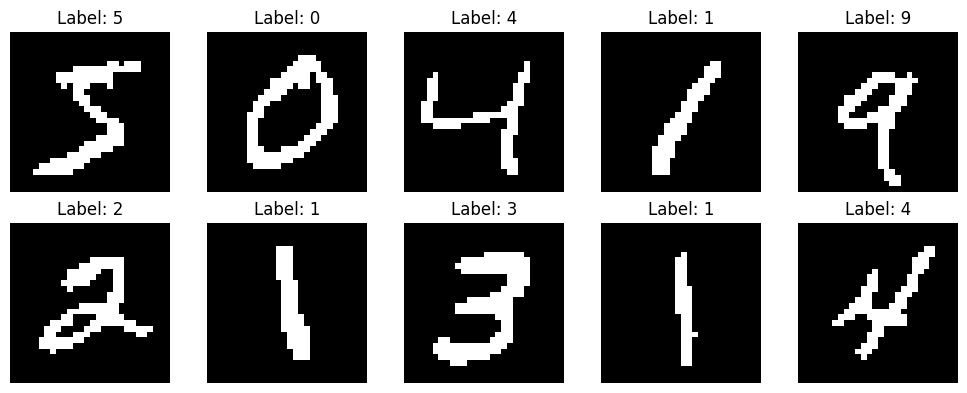

In [ ]:
# MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    # Threshold at 0.5 to create binary images
    lambda x: (x > 0.5).float().clamp(0,1)
])


#train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Training dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# Test dataset
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Display some example images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_dataset[i][0].squeeze().numpy(), cmap='gray')
    plt.title(f"Label: {train_dataset[i][1]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


# Autoencoder Reconstruction

In [ ]:
# Implement CNN-based autoencoder
class ConvAE(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1), # 1 * 28 * 28 -> 16 * 14 * 14
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # 16 * 14 * 14 -> 32 * 7 * 7
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(7*7*32, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 7*7*32),
            nn.Unflatten(1, (32,7,7)),
            nn.ConvTranspose2d(32,16,3,stride=2,padding=1,output_padding=1), #32 * 7 *7 -> 16* 14* 14
            nn.ReLU(),
            nn.ConvTranspose2d(16,1,3,stride=2,padding=1,output_padding=1), #16*14*14 -> 1 * 28 * 28
            nn.Sigmoid()
        )

    def forward(self, x):
        # Encode
        latent = self.encoder(x) # z-> latent vector
        # Decode
        reconstructed = self.decoder(latent)
        # Reshape to original image dimensions
        reconstructed = reconstructed.view(-1, 1, 28, 28)
        return reconstructed, latent

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        reconstructed = self.decoder(z)
        return reconstructed.view(-1, 1, 28, 28)

# Binary Cross Entropy Loss
def bce_loss(recon_x, x):
    return nn.BCELoss(reduction='sum')(recon_x, x)



In [ ]:
def train_autoencoder(model, train_loader, test_loader, num_epochs=10,
                      learning_rate=1e-3, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    test_losses = []

    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for batch_idx, (data, _) in enumerate(progress_bar):
            data = data.to(device)
            optimizer.zero_grad()

            # Forward pass
            recon_batch, _ = model(data)
            loss = nn.BCELoss(reduction='sum')(recon_batch, data)


            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            # Update progress bar
            progress_bar.set_postfix(loss=loss.item()/len(data))

        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for data, _ in test_loader:
                data = data.to(device)
                recon_batch, _ = model(data)
                loss = nn.BCELoss(reduction='sum')(recon_batch, data)

                test_loss += loss.item()

        test_loss /= len(test_loader.dataset)
        test_losses.append(test_loss)

        print(f'====> Epoch: {epoch+1} Average train loss: {train_loss:.6f}, Test loss: {test_loss:.6f}')

    return train_losses, test_losses



#Train Auto-Encoder

In [ ]:
# Setting hyperparameters
latent_dim = 64
num_epochs = 6  # Can be increased for better results

# Initialize models
ae_model = ConvAE(latent_dim=latent_dim)


# Train with loss
print("Training autoencoder with  loss...")
train_losses, test_losses = train_autoencoder(ae_model, train_loader, test_loader, num_epochs=num_epochs, device=device)

Training autoencoder with  loss...


Epoch 1/6: 100%|██████████| 469/469 [00:11<00:00, 41.57it/s, loss=42.7]


====> Epoch: 1 Average train loss: 120.584130, Test loss: 44.603858


Epoch 2/6: 100%|██████████| 469/469 [00:10<00:00, 46.28it/s, loss=27.7]


====> Epoch: 2 Average train loss: 34.989468, Test loss: 26.958937


...

====> Epoch: 4 Average train loss: 19.581429, Test loss: 17.835295


Epoch 5/6: 100%|██████████| 469/469 [00:10<00:00, 45.75it/s, loss=16.7]


====> Epoch: 5 Average train loss: 17.169421, Test loss: 16.282321


Epoch 6/6: 100%|██████████| 469/469 [00:10<00:00, 46.47it/s, loss=14.9]


====> Epoch: 6 Average train loss: 15.638293, Test loss: 15.026236


## Visualize Reconstruction

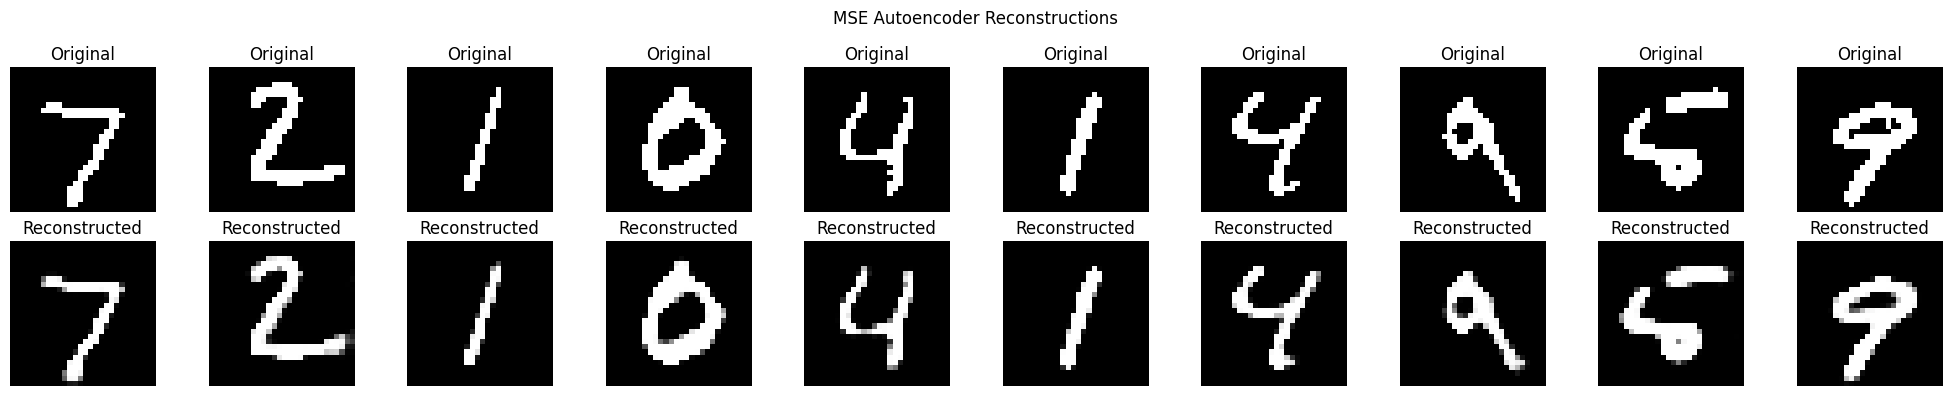

In [ ]:
# Function to visualize reconstructions
def visualize_reconstructions(model, data_loader, title, num_images=10,
                             device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.eval()
    with torch.no_grad():
        for batch_idx, (data, _) in enumerate(data_loader):
            original_data = data[:num_images].to(device)
            reconstructed_data, _ = model(original_data)

            plt.figure(figsize=(20, 4))

            # Original images
            for i in range(num_images):
                plt.subplot(2, num_images, i + 1)
                plt.imshow(original_data[i].cpu().numpy().reshape(28, 28), cmap='gray')
                plt.title('Original')
                plt.axis('off')

            # Reconstructed images
            for i in range(num_images):
                plt.subplot(2, num_images, num_images + i + 1)
                plt.imshow(reconstructed_data[i].cpu().numpy().reshape(28, 28), cmap='gray')
                plt.title('Reconstructed')
                plt.axis('off')

            plt.suptitle(title)
            plt.tight_layout()
            plt.show()
            break  # Only plot one batch

# Visualize reconstructions for each model
visualize_reconstructions(ae_model, test_loader, "MSE Autoencoder Reconstructions")

## Let's try to synthesize new data points.

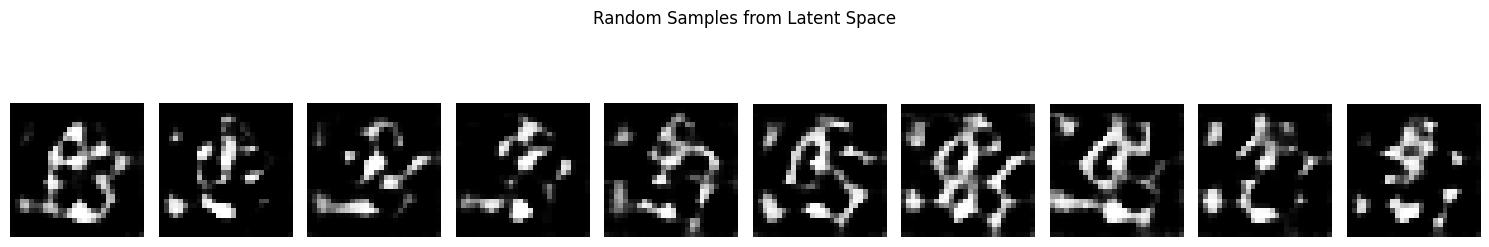

In [ ]:
# Sample from latent space
def sample_latent_space(model, num_samples=10, latent_dim=20,
                        device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.eval()
    with torch.no_grad():
        # Generate random points in latent space
        z = torch.randint(5, size=(num_samples, latent_dim)).float().to(device)
        # Decode the random points
        samples = model.decode(z)

        plt.figure(figsize=(15, 3))
        for i in range(num_samples):
            plt.subplot(1, num_samples, i + 1)
            plt.imshow(samples[i].cpu().numpy().reshape(28, 28), cmap='gray')
            plt.axis('off')
        plt.suptitle("Random Samples from Latent Space")
        plt.tight_layout()
        plt.show()

# Sample from the latent space of the combined loss model
sample_latent_space(ae_model, num_samples=10, latent_dim=latent_dim, device=device)


## 3. Reconstruction Loss Definition
According to the slides, for binary data like MNIST, we use Binary Cross-Entropy loss which corresponds to a Bernoulli likelihood model:

In [ ]:
def reconstruction_loss(x, x_recon):
    """
    Binary Cross-Entropy loss for Bernoulli likelihood model.

    For binary data (MNIST):
    -log p(x|z) = -∑[x_i * log(θ_i(z)) + (1-x_i) * log(1-θ_i(z))]

    where θ_i(z) is the probability of pixel i being 1, decoded from latent code z.
    This matches the Bernoulli likelihood description from slide 133.
    """
    # BCELoss expects inputs in range [0, 1]
    # Each pixel value in x_recon is interpreted as the probability of that pixel being 1
    BCE = F.binary_cross_entropy(x_recon, x, reduction='sum')
    return BCE


## 4. KL Divergence Loss Definition
From the slides, the KL divergence between our approximate posterior q(z|x) and the prior p(z) acts as a regularization term:

In [ ]:
def kl_divergence(mu, logvar):
    """
    KL divergence between q(z|x) = N(μ(x), σ²(x)) and p(z) = N(0, I).

    As shown in slides:
    D_KL(q(z|x) || p(z)) = 1/2 ∑(μ² + σ² - log(σ²) - 1)

    For the standard normal prior p(z) = N(0, I), this simplifies to the formula below.
    """
    # -0.5 * sum(1 + log(σ²) - μ² - σ²)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return KLD


## 5. KL Annealing Implementation
As mentioned in the slides, KL annealing is a technique to gradually increase the weight of the KL term during training, which helps prevent posterior collapse:

In [ ]:
def get_beta(step, warmup_steps, max_beta=1.0):
    """
    Linear KL annealing schedule (as shown in slide 142).

    Args:
        step: Current training step
        warmup_steps: Number of warmup steps
        max_beta: Maximum β value (default: 1.0)

    Returns:
        β value for the current step
    """
    if step > warmup_steps:
        return max_beta
    else:
        return max_beta * (step / warmup_steps)


## 6. CNN-Based VAE Model Implementation
Using the architecture guidelines from the slides (specifically slide 128 for CNN architectures):

In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=4):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder (following CNN architecture recommendations in slides)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=4, stride=2, padding=1),  # 28x28 -> 14x14
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=4, stride=2, padding=1),  # 14x14 -> 7x7
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),  # 7x7 -> 7x7
            nn.ReLU(),
            nn.Flatten()
        )

        # Calculate the size of the encoder output
        self.encoder_output_size = 32 * 7 * 7

        # Mean and log-variance layers
        self.fc_mu = nn.Linear(self.encoder_output_size, latent_dim)
        self.fc_logvar = nn.Linear(self.encoder_output_size, latent_dim)

        #------completes encoder-----

        # Decoder initial fully connected layer
        self.decoder_input = nn.Linear(latent_dim, 7 * 7 * 32)

        # Decoder (using ConvTranspose layers as suggested in slides)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),  # 7x7 -> 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 8, kernel_size=4, stride=2, padding=1),  # 14x14 -> 28x28
            nn.ReLU(),
            nn.Conv2d(8, 1, kernel_size=3, stride=1, padding=1),  # 28x28 -> 28x28
            nn.Sigmoid()  # Output pixels in [0,1] range for BCE loss
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        logvar = torch.clamp(logvar, min=-10, max=10)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick as described in slides 109-110.
        Instead of sampling directly from q(z|x), we sample from
        epsilon ~ N(0,I) and compute z = mu + sigma * epsilon
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_input(z)
        h = h.view(-1, 32, 7, 7)  # Reshape for ConvTranspose layers
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

# Initialize model
model = VAE().to(device)
print(model)


VAE(
  (encoder): Sequential(
    (0): Conv2d(1, 8, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(8, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=1568, out_features=4, bias=True)
  (fc_logvar): Linear(in_features=1568, out_features=4, bias=True)
  (decoder_input): Linear(in_features=4, out_features=1568, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(16, 8, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(8, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): Sigmoid()
  )
)


## 7. Training Loop with KL Annealing

In [ ]:
def train(model, train_loader, optimizer, epochs=30, warmup_steps=10000, max_beta=1.0):
    model.train()
    train_losses = []
    kl_losses = []
    recon_losses = []
    step = 0

    for epoch in range(epochs):
        epoch_loss = 0
        epoch_recon_loss = 0
        epoch_kl_loss = 0

        progress_bar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{epochs}")

        for i, (x, _) in progress_bar:

            x = x.to(device)
            optimizer.zero_grad()

            # Forward pass
            x_recon, mu, logvar = model(x)

            # Calculate losses
            recon_loss = reconstruction_loss(x, x_recon)
            kl_loss = kl_divergence(mu, logvar)

            # Apply KL annealing
            beta = get_beta(step, warmup_steps, max_beta)

            # Total loss (following the ELBO objective from slide 133)
            loss = recon_loss + beta * kl_loss

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            # Update metrics
            epoch_loss += loss.item()
            epoch_recon_loss += recon_loss.item()
            epoch_kl_loss += kl_loss.item()

            # Update progress bar
            progress_bar.set_postfix({
                'loss': loss.item() / len(x),
                'recon_loss': recon_loss.item() / len(x),
                'kl_loss': kl_loss.item() / len(x),
                'beta': beta
            })

            step += 1

        # Compute average losses
        avg_loss = epoch_loss / len(train_loader.dataset)
        avg_recon_loss = epoch_recon_loss / len(train_loader.dataset)
        avg_kl_loss = epoch_kl_loss / len(train_loader.dataset)

        train_losses.append(avg_loss)
        recon_losses.append(avg_recon_loss)
        kl_losses.append(avg_kl_loss)

        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Recon Loss: {avg_recon_loss:.4f}, KL Loss: {avg_kl_loss:.4f}, Beta: {beta:.4f}")

    return train_losses, recon_losses, kl_losses

# Initialize optimizer (Adam as recommended in the slides)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Train model
print("Starting training...")
train_losses, recon_losses, kl_losses = train(model, train_loader, optimizer, epochs=16, warmup_steps=2000)
print("Training complete!")


Starting training...


Epoch 1/16: 100%|██████████| 469/469 [00:11<00:00, 41.16it/s, loss=145, recon_loss=142, kl_loss=12.7, beta=0.234]


Epoch 1/16, Loss: 198.0672, Recon Loss: 196.0170, KL Loss: 22.6278, Beta: 0.2340


Epoch 2/16: 100%|██████████| 469/469 [00:11<00:00, 40.44it/s, loss=123, recon_loss=117, kl_loss=12.4, beta=0.469]


Epoch 2/16, Loss: 136.5941, Recon Loss: 132.2505, KL Loss: 12.4244, Beta: 0.4685


...

Epoch 14/16, Loss: 124.7196, Recon Loss: 114.5639, KL Loss: 10.1556, Beta: 1.0000


Epoch 15/16: 100%|██████████| 469/469 [00:11<00:00, 40.07it/s, loss=115, recon_loss=105, kl_loss=10.4, beta=1]


Epoch 15/16, Loss: 124.4043, Recon Loss: 114.2240, KL Loss: 10.1803, Beta: 1.0000


Epoch 16/16: 100%|██████████| 469/469 [00:11<00:00, 41.11it/s, loss=121, recon_loss=111, kl_loss=10.1, beta=1]

Epoch 16/16, Loss: 124.1139, Recon Loss: 113.8944, KL Loss: 10.2195, Beta: 1.0000
Training complete!


## 8. Plot Training Metrics

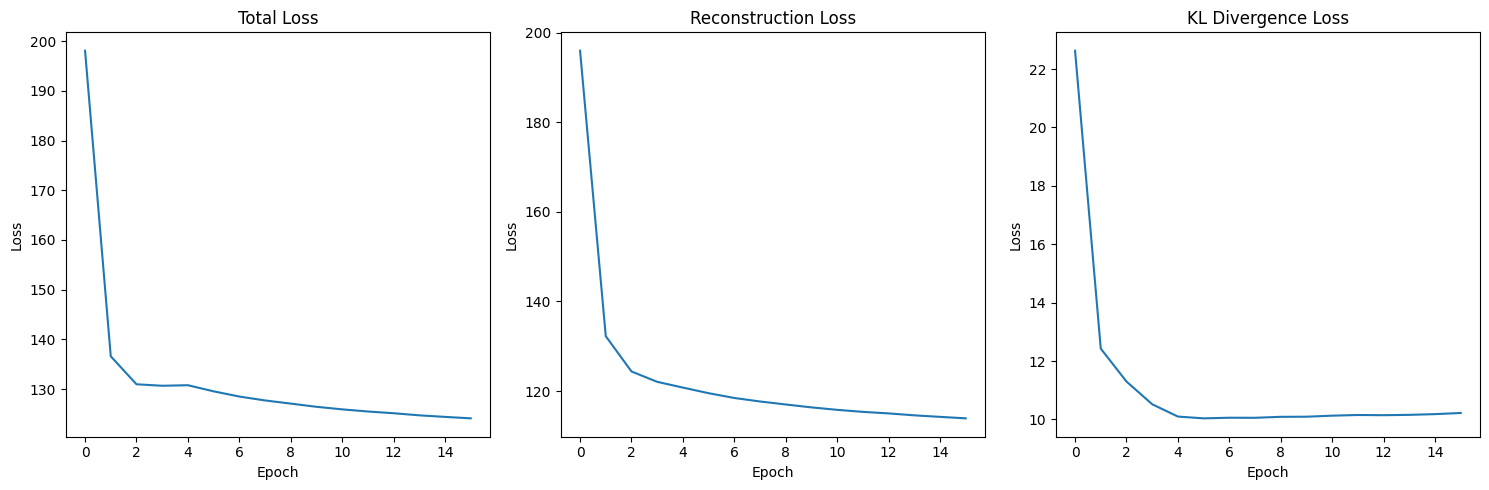

In [ ]:
# Plot training losses
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses)
plt.title('Total Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 3, 2)
plt.plot(recon_losses)
plt.title('Reconstruction Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 3, 3)
plt.plot(kl_losses)
plt.title('KL Divergence Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

## 9. Evaluate and Visualize Reconstructions

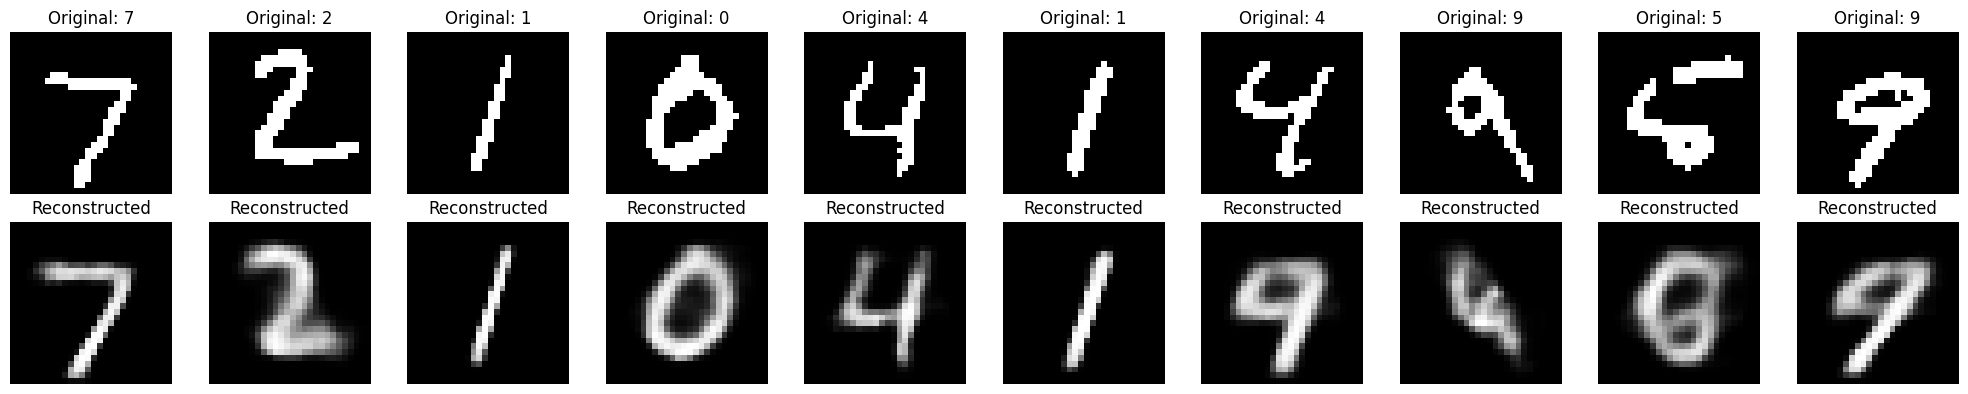

In [ ]:
def visualize_reconstructions(model, test_loader, n=10):
    model.eval()

    # Get batch of test images
    dataiter = iter(test_loader)
    images, labels = next(dataiter)
    images = images[:n].to(device)

    # Reconstruct images
    with torch.no_grad():
        reconstructions, _, _ = model(images)

    # Plot original vs reconstructed images
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # Original images
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(images[i].cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Original: {labels[i]}")
        plt.axis('off')

        # Reconstructed images
        ax = plt.subplot(2, n, n + i + 1)
        plt.imshow(reconstructions[i].cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Reconstructed")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Visualize reconstructions
visualize_reconstructions(model, test_loader)


## 10. Generate Samples from the Latent Space
As described in slides, we can sample from the prior distribution and decode to generate new samples:

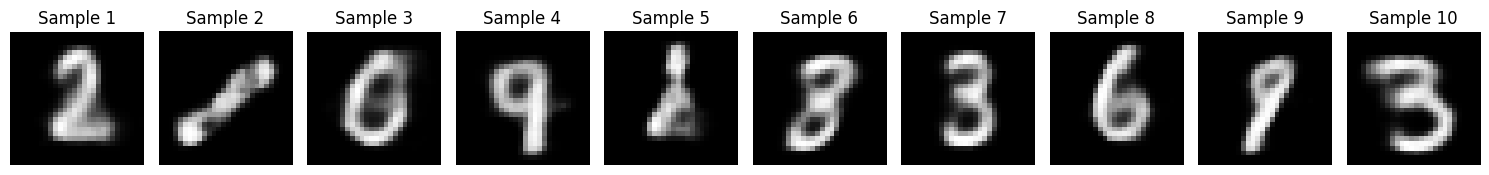

In [ ]:
def generate_samples(model, num_samples=10):
    model.eval()

    with torch.no_grad():
        # Sample from the latent space (prior p(z) = N(0, I))
        z = torch.randn(num_samples, model.latent_dim).to(device)

        # Decode samples
        samples = model.decode(z)

    # Plot generated samples
    plt.figure(figsize=(15, 3))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(samples[i].cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Sample {i+1}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Generate samples
generate_samples(model)


## 11. Latent Space Interpolation
As mentioned in slide 104, interpolation in the latent space reveals the continuous structure learned by the VAE:

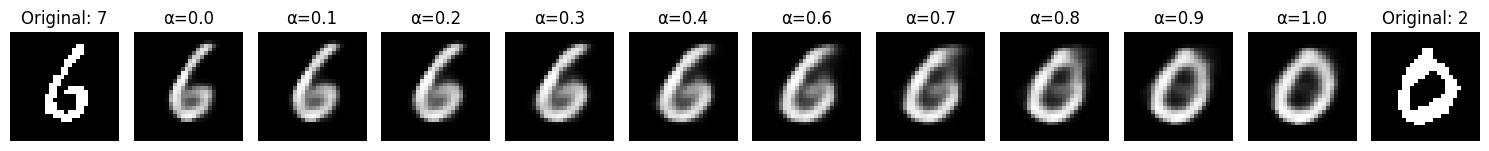

In [ ]:
def interpolate_latent_space(model, test_loader, steps=10):
    model.eval()

    # Get two test images
    dataiter = iter(test_loader)
    images, labels = next(dataiter)
    image1 = images[50:51].to(device)
    image2 = images[3:4].to(device)

    # Encode images to get latent representations
    with torch.no_grad():
        mu1, logvar1 = model.encode(image1)
        mu2, logvar2 = model.encode(image2)

        # Use means as the representations
        z1 =  mu1
        z2 =  mu2

    # Interpolate between the latent representations
    interpolations = []
    for alpha in np.linspace(0, 1, steps):
        z_interp = z1 * (1 - alpha) + z2 * alpha
        # Decode interpolated latent vector
        with torch.no_grad():
            interp_image = model.decode(z_interp)
            interpolations.append(interp_image.cpu().squeeze().numpy())

    # Plot original images and interpolations
    plt.figure(figsize=(15, 3))

    # Original image 1
    plt.subplot(1, steps + 2, 1)
    plt.imshow(image1.cpu().squeeze().numpy(), cmap='gray')
    plt.title(f"Original: {labels[0]}")
    plt.axis('off')

    # Interpolations
    for i in range(steps):
        plt.subplot(1, steps + 2, i + 2)
        plt.imshow(interpolations[i], cmap='gray')
        plt.title(f"α={i/(steps-1):.1f}")
        plt.axis('off')

    # Original image 2
    plt.subplot(1, steps + 2, steps + 2)
    plt.imshow(image2.cpu().squeeze().numpy(), cmap='gray')
    plt.title(f"Original: {labels[1]}")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Interpolate in latent space
interpolate_latent_space(model, test_loader)


## TODO-1 -> β-VAE: Exploring the Effect of the Beta Hyperparameter

Modify your VAE loss function to include a β (beta) multiplier on the KL divergence term.  
- Train your model with different values of β (e.g., 0.5, 1, 2, 4).
- Plot and compare the reconstruction loss, KL divergence, and generated samples for each value.
- Discuss: How does increasing β affect the trade-off between reconstruction quality and latent space regularization?

In [ ]:
# TODO: Modify your training loop to accept a beta parameter
# Example: loss = recon_loss + beta * kl_loss
beta = 4.0  # Try different values
# ... rest of your training loop here


### TODO-2: Latent Traversals

For a trained VAE, fix all latent variables except one and vary that dimension.
- Visualize the generated images as you sweep through the latent dimension.
- Discuss: Do certain dimensions correspond to interpretable features


In [ ]:
# TODO: Implement latent traversal visualization
# For each dimension, vary z_i in [-3, 3] while fixing others


## TODO-3: VAE on CIFAR-100


Replace the MNIST dataset with CIFAR-100.
- Adjust the network architecture if needed.
- Train and evaluate your VAE on the new dataset.
- Compare reconstruction and generation quality with your MNIST results.

**Hint: BCE may not be the best option for CIFAR-100**


100%|██████████| 169M/169M [00:03<00:00, 48.9MB/s]


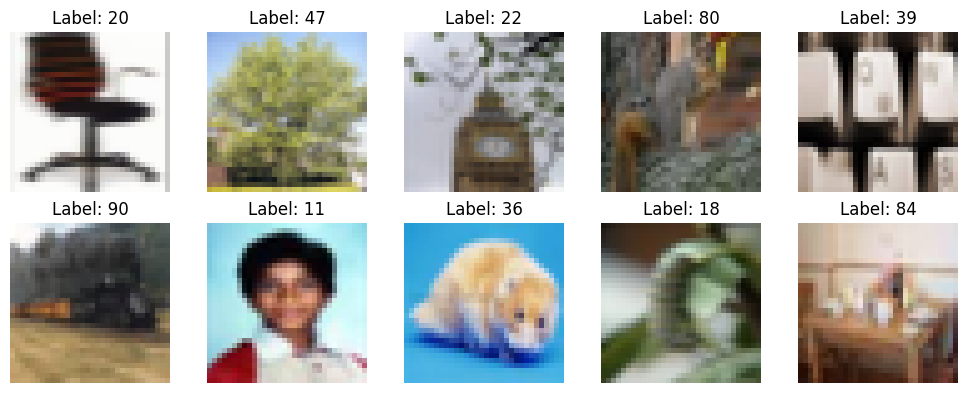

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import random

# Define transformation: ToTensor() converts images to [0,1] float tensors
transform = transforms.Compose([
    transforms.ToTensor()
])

# Load Fashion-MNIST training and test datasets
train_dataset = datasets.CIFAR100(
    root='data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR100(
    root='data',
    train=False,
    download=True,
    transform=transform
)

# Create DataLoaders
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# Display some example images
plt.figure(figsize=(10, 4))
for idx, i in enumerate(random.sample(range(128),10)):
    plt.subplot(2, 5, idx + 1)
    plt.imshow(train_dataset[i][0].permute(1, 2, 0).numpy())
    plt.title(f"Label: {train_dataset[i][1]}")
    plt.axis('off')
plt.tight_layout()
plt.show()